In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

from watobs import CMEMSSatObsRepository

import copernicusmarine

# First time users
First time users of the Copernicus Marine API will need to create an account at https://marine.copernicus.eu/ and generate an API key.

Below you call the login function to authenticate your credentials. You only have to do this the first time you use the API on a PC.



In [2]:
if not CMEMSSatObsRepository.validate_login():
    copernicusmarine.login()

### Specify dataset of product to be downloaded from CMEMS Online Catalogue
- Click through the catalogue here: https://data.marine.copernicus.eu/products?pk_vid=bfd50509683fc0421764148768aca348 

Options are currently:
- "WAVE_GLO_PHY_SWH_L3_MY_014_005" 
- "WAVE_GLO_PHY_SWH_L3_NRT_014_001" 
- "WIND_GLO_PHY_L3_MY_012_005" 
- "WIND_GLO_PHY_L3_NRT_012_002"

Ideally there would be a better way to specify this in the future

In [3]:
repo = CMEMSSatObsRepository("WIND_GLO_PHY_L3_MY_012_005")

Loading CMEMS product id: WIND_GLO_PHY_L3_MY_012_005
	Done!


### Datasets from product `WIND_GLO_PHY_L3_NRT_012_002`
- A total of 16 datasets, i.e. data from 8 different satellite missions, 2 orbits (asc/desc) each, are available in the catalogue for this product. (32 datasets if you include the coarser resolutions)

In [4]:
datasets = repo.datasets
datasets.head()

name='default' services=[CopernicusMarineService(service_name='original-files', service_short_name='files', service_format=None, uri='https://s3.waw3-1.cloudferro.com/mdl-native-04/native/WIND_GLO_PHY_L3_MY_012_005/cmems_obs-wind_glo_phy_my_l3-ers1-scat-asc-0.25deg_P1D-i_202311', variables=[CopernicusMarineVariable(short_name='air_density', standard_name='air_density', units='kg m-3', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='bs_distance', standard_name='backscatter_distance_to_modelfunction', units='1', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='eastward_model_stress', standard_name='surface_downward_eastward_stress', units='N m-2', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='eastward_stress', standard_name='surface_downward_eastward_stress', units='N m-2', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), Copernicu

,source,source_type,obs_type,coverage,ocean_category,param,multiyear_or_nearrealtime,short_name,processing_level,asc_desc,spatial_resolution,temporal_resolution,temporal_type,min_date,max_date
dataset_id,,,,,,,,,,,,,,,
cmems_obs-wind_glo_phy_my_l3-ers1-scat-asc-0.25deg_P1D-i,cmems,obs,wind,glo,phy,None,my,ers1,l3,asc,0.25deg,P1D,i,1991-08-01 00:00:00+00:00,1996-06-02 00:00:00+00:00
cmems_obs-wind_glo_phy_my_l3-ers1-scat-des-0.25deg_P1D-i,cmems,obs,wind,glo,phy,None,my,ers1,l3,des,0.25deg,P1D,i,1991-08-01 00:00:00+00:00,1996-06-02 00:00:00+00:00
cmems_obs-wind_glo_phy_my_l3-ers2-scat-asc-0.25deg_P1D-i,cmems,obs,wind,glo,phy,None,my,ers2,l3,asc,0.25deg,P1D,i,1996-03-20 00:00:00+00:00,2001-01-17 00:00:00+00:00
cmems_obs-wind_glo_phy_my_l3-ers2-scat-des-0.25deg_P1D-i,cmems,obs,wind,glo,phy,None,my,ers2,l3,des,0.25deg,P1D,i,1996-03-20 00:00:00+00:00,2001-01-17 00:00:00+00:00
cmems_obs-wind_glo_phy_my_l3-metopa-ascat-asc-0.125deg_P1D-i,cmems,obs,wind,glo,phy,None,my,metopa,l3,asc,0.125deg,P1D,i,2007-01-01 00:00:00+00:00,2021-11-15 00:00:00+00:00


# Lets just choose the first satellite mission for simplicity
- In this case, i am interested in data from 2019 only
- In addition i want to see data in the North Sea west of the Danish coastline

In [5]:
repo.dataset_ids

name='default' services=[CopernicusMarineService(service_name='original-files', service_short_name='files', service_format=None, uri='https://s3.waw3-1.cloudferro.com/mdl-native-04/native/WIND_GLO_PHY_L3_MY_012_005/cmems_obs-wind_glo_phy_my_l3-ers1-scat-asc-0.25deg_P1D-i_202311', variables=[CopernicusMarineVariable(short_name='air_density', standard_name='air_density', units='kg m-3', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='bs_distance', standard_name='backscatter_distance_to_modelfunction', units='1', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='eastward_model_stress', standard_name='surface_downward_eastward_stress', units='N m-2', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='eastward_stress', standard_name='surface_downward_eastward_stress', units='N m-2', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), Copernicu

['cmems_obs-wind_glo_phy_my_l3-ers1-scat-asc-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-ers1-scat-des-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-ers2-scat-asc-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-ers2-scat-des-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-metopa-ascat-asc-0.125deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-metopb-ascat-asc-0.125deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-metopb-ascat-des-0.125deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-oceansat2-oscat-asc-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-oceansat2-oscat-des-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-quikscat-seawinds-asc-0.25deg_P1D-i',
 'cmems_obs-wind_glo_phy_my_l3-quikscat-seawinds-des-0.25deg_P1D-i']

In [6]:
dataset = repo.dataset_ids[5]

start_time="2019-01-01"
end_time="2019-12-31"

lon_min = 105
lat_min = -5
lon_max = 145
lat_max = 40

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

name='default' services=[CopernicusMarineService(service_name='original-files', service_short_name='files', service_format=None, uri='https://s3.waw3-1.cloudferro.com/mdl-native-04/native/WIND_GLO_PHY_L3_MY_012_005/cmems_obs-wind_glo_phy_my_l3-ers1-scat-asc-0.25deg_P1D-i_202311', variables=[CopernicusMarineVariable(short_name='air_density', standard_name='air_density', units='kg m-3', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='bs_distance', standard_name='backscatter_distance_to_modelfunction', units='1', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='eastward_model_stress', standard_name='surface_downward_eastward_stress', units='N m-2', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), CopernicusMarineVariable(short_name='eastward_stress', standard_name='surface_downward_eastward_stress', units='N m-2', bbox=[-179.875, -89.875, 179.875, 89.875], coordinates=[]), Copernicu

In [7]:
df = repo.get_satobs_data(
    dataset_id=dataset, # we can disable this comment to download one dataset at a time
    start_time=start_time,
    end_time=end_time,
    area=area,
)

-- Downloading subset of cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i


INFO - 2025-12-05T10:01:17Z - Selected dataset version: "202311"
INFO - 2025-12-05T10:01:17Z - Selected dataset part: "default"


KeyboardInterrupt: 

### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

In [47]:
df.head()

,longitude,latitude,WS,WD,U10,V10
time,,,,,,
2019-01-01 01:29:36,107.4375,-4.9375,12.92,111.1,12.03,-4.64
2019-01-01 01:29:36,107.5625,-4.9375,13.35,104.5,12.92,-3.30
2019-01-01 01:29:36,107.6875,-4.9375,14.87,100.5,14.60,-2.68
2019-01-01 01:29:36,107.8125,-4.9375,18.05,137.3,6.94,-10.31
2019-01-01 01:29:36,107.9375,-4.9375,19.21,154.9,3.42,-14.02


In [93]:
import pandas as pd

df_reduced = df[(df.index > pd.Timestamp("2019-09-04 01:22")) & (df.index < pd.Timestamp("2019-09-04 01:29"))]

### Plotting
- Lets plot and see the data

In [96]:
df_reduced_twice = df_reduced[df_reduced.longitude > 115]

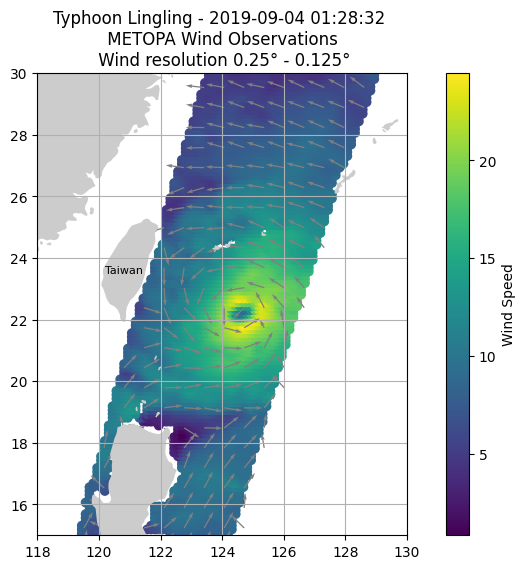

In [119]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from scipy.interpolate import griddata

coastline = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_coastline.geojson")
countries = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")


# Create a matplotlib Axes object
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(df_reduced_twice['longitude'], df_reduced_twice['latitude'],
                c=df_reduced_twice['WS'], cmap='viridis', label='Data Points')
plt.colorbar(sc, ax=ax, label='Wind Speed')

# Original coordinates and wind components
lon = df_reduced_twice['longitude'].values
lat = df_reduced_twice['latitude'].values

# Create structured grid (every 0.5 degrees)
lon_grid = np.arange(lon.min(), lon.max(), 0.65)
lat_grid = np.arange(lat.min(), lat.max(), 0.65)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate u and v onto the grid
# Be wary about the sign convention here!
wd_rad = np.deg2rad(df_reduced_twice['WD'])
u = np.sin(wd_rad)  # East-West component
v = np.cos(wd_rad)  # North-South component
u_grid = griddata((lon, lat), u, (lon_mesh, lat_mesh), method='linear')
v_grid = griddata((lon, lat), v, (lon_mesh, lat_mesh), method='linear')


from scipy.spatial import cKDTree
import numpy as np

# Build KDTree for original observation points
tree = cKDTree(np.c_[lon, lat])

# Compute distance from each grid point to nearest observation
dist, _ = tree.query(np.c_[lon_mesh.ravel(), lat_mesh.ravel()])
dist = dist.reshape(lon_mesh.shape)

# Define a threshold (in degrees) beyond which arrows are masked
threshold = 0.5  # Adjust based on swath width
mask = dist > threshold

# Apply mask to u and v grids
u_grid[mask] = np.nan
v_grid[mask] = np.nan

# Plot quiver with masked data
q2 = ax.quiver(lon_mesh, lat_mesh, u_grid, v_grid, scale=20, width=0.0035, color='grey')
## Plot quiver on structured grid
#q2 = ax.quiver(lon_mesh, lat_mesh, u_grid, v_grid, scale=45, width=0.002, color='grey')

countries.plot(ax=ax, color='0.8')

xlim = (118, 130)
ylim = (15, 30)

for idx, row in countries.iterrows():
    point = row['geometry'].representative_point()
    if xlim[0] <= point.x <= xlim[1] and ylim[0] <= point.y <= ylim[1]:
        ax.text(point.x, point.y, row['admin'], fontsize=8, ha='center', va='center')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect(1.0 / np.cos(np.pi * 1 / 180))
ax.grid(True)

ax.set_title(f'Typhoon Lingling - {df_reduced_twice.index[0]} \n METOPA Wind Observations \n Wind resolution 0.25° - 0.125°')

plt.show()

In [ ]:
repo = CMEMSSatObsRepository("WIND_GLO_PHY_L3_MY_012_005")

C:\Users\raiw\AppData\Local\Temp\ipykernel_55672\4261721393.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, 'Typhoon Lingling - 2019-09-04 01:28:32 \n METOPA Wind Observations \n Wind resolution 0.25° - 0.125° \n Wave resolution 7 x 7 km \n Spectral resolution 70 x 70 km')

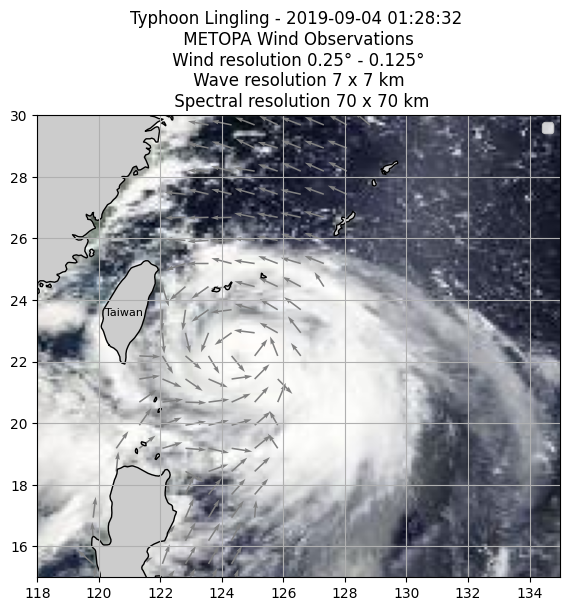

In [111]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#wd_rad = np.deg2rad(df_reduced_twice['WD'])
#wave_d_rad = np.deg2rad(df_wave_spec_reduced['VPED'])

# Calculate vector components
# Here wind blow towards, therefore no negative sign
#u = np.sin(wd_rad)  # East-West component
#v = np.cos(wd_rad)  # North-South component
#u_w = np.sin(wave_d_rad)  # East-West component
#v_w = np.cos(wave_d_rad)  # North-South component

# Load background image
img = mpimg.imread('snapshot-2019-09-04.jpg')
# https://wvs.earthdata.nasa.gov/api/v1/snapshot?REQUEST=GetSnapshot&TIME=2019-09-04T00:00:00Z&BBOX=13.5308,117.0052,30.8115,132.4344&CRS=EPSG:4326&LAYERS=MODIS_Terra_CorrectedReflectance_TrueColor,Coastlines_15m&WRAP=day,x&FORMAT=image/jpeg&WIDTH=1756&HEIGHT=1966&colormaps=,&ts=1761728036609

# Create a matplotlib Axes object
fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(img, extent=[117.0052, 135, 13.5308, 30.8115], origin='upper')

#sc = ax.scatter(df_wave_reduced['longitude'], df_wave_reduced['latitude'],
#                c=df_wave_reduced['SWH'], cmap='viridis', vmax = 4, vmin = 0, label='nadir data Points')

#sc_spec = ax.scatter(df_wave_spec_reduced['longitude'], df_wave_spec_reduced['latitude'],
#                c=df_wave_spec_reduced['SWH'], marker='s', cmap='viridis', vmax = 4, vmin = 0, label='Spectral data Points')
#plt.colorbar(sc, ax=ax, label='nadir SWH')
#plt.colorbar(sc_spec, ax=ax, label='Spectral SWH')

# Original coordinates and wind components
#lon = df_reduced_twice['longitude'].values
#lat = df_wind_reduced['latitude'].values
#wd_rad = np.deg2rad(df_wind_reduced['WD'].values)
#u = np.sin(wd_rad)
#v = np.cos(wd_rad)

# Create structured grid (every 0.5 degrees)
#lon_grid = np.arange(lon.min(), lon.max(), 0.5)
#lat_grid = np.arange(lat.min(), lat.max(), 0.5)
#lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate u and v onto the grid
#u_grid = griddata((lon, lat), u, (lon_mesh, lat_mesh), method='linear')
#v_grid = griddata((lon, lat), v, (lon_mesh, lat_mesh), method='linear')
# Plot quiver on structured grid
q2 = ax.quiver(lon_mesh, lat_mesh, u_grid, v_grid, scale=25, width=0.003, color='grey')

#q = ax.quiver(df_wind_reduced['longitude'][0::5], df_wind_reduced['latitude'][0::5],
#              u, v, scale=45, width=0.002, color='grey')
#q_w = ax.quiver(df_wave_spec_reduced['longitude'], df_wave_spec_reduced['latitude'],
#              u_w, v_w, scale=45, width=0.002, color='red')

ax.legend()

xlim = (118, 135)
ylim = (15, 30)

# Plot countries
countries.plot(ax=ax, color='0.8', edgecolor='black')

# Add labels only for countries within the visible bounds
for idx, row in countries.iterrows():
    point = row['geometry'].representative_point()
    if xlim[0] <= point.x <= xlim[1] and ylim[0] <= point.y <= ylim[1]:
        ax.text(point.x, point.y, row['admin'], fontsize=8, ha='center', va='center')

# Lock axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.grid(True)
# Resolution documentation:
# Wind: https://data.marine.copernicus.eu/product/WIND_GLO_PHY_L3_NRT_012_002/description
# Wave: https://data.marine.copernicus.eu/product/WAVE_GLO_PHY_SWH_L3_NRT_014_001/description
# Spectral: https://data.marine.copernicus.eu/product/WAVE_GLO_PHY_SPC_L3_NRT_014_009/description
ax.set_title(f'Typhoon Lingling - {df_reduced_twice.index[0]} \n METOPA Wind Observations \n Wind resolution 0.25° - 0.125° \n Wave resolution 7 x 7 km \n Spectral resolution 70 x 70 km')

# Repeat 4 SWH


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

from watobs import CMEMSSatObsRepository

import copernicusmarine

In [13]:
repo = CMEMSSatObsRepository("WAVE_GLO_PHY_SWH_L3_NRT_014_001")

Loading CMEMS product id: WAVE_GLO_PHY_SWH_L3_NRT_014_001
	Done!


In [14]:
repo.get_observation_stats()

,min_date,max_date
short_name,,
al,2021-01-01 00:27:03+00:00,2025-12-02 10:48:57+00:00
c2,2021-01-01 00:00:00+00:00,2025-12-02 12:49:03+00:00
cfo,2021-01-01 00:34:11+00:00,2025-12-02 11:11:24+00:00
h2b,2021-01-01 00:00:00+00:00,2025-11-30 22:49:57+00:00
h2c,2022-12-01 01:07:06+00:00,2025-11-30 22:48:25+00:00
j3,2021-01-01 00:08:17+00:00,2025-12-02 12:02:02+00:00
s3a,2021-01-01 00:14:33+00:00,2025-12-02 12:15:59+00:00
s3b,2021-01-01 00:00:39+00:00,2025-12-02 11:38:28+00:00
s6a,2021-09-21 00:02:30+00:00,2025-12-02 12:05:17+00:00


C:\Users\raiw\Desktop\cloned_repos\watobs\watobs\altimetry.py:297: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  yearly = pd.date_range(start="1984-1-1", end=end_date, freq="2AS")


<Axes: title={'center': 'Satellite lifespan'}>

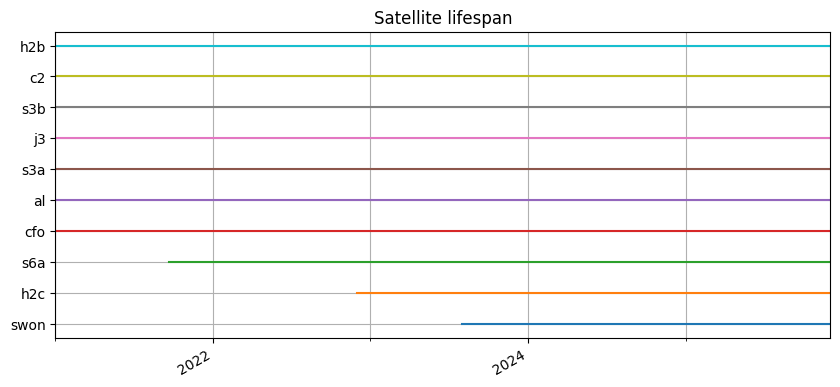

In [15]:
repo.plot_observation_stats()

# Lets just choose the first satellite mission for simplicity
- In this case, i am interested in data from 2019 only
- In addition i want to see data in the North Sea west of the Danish coastline

In [16]:
dataset = repo.dataset_ids[0]

start_time="2021-01-01"
end_time="2021-12-31"

lon_min = 6
lon_max = 9
lat_min = 55
lat_max = 57.5

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [17]:
df = repo.get_satobs_data(
    #dataset_id=dataset, # we can disable this comment to download one dataset at a time
    start_time=start_time,
    end_time=end_time,
    area=area,
)

-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S


INFO - 2025-12-02T14:42:45Z - Selected dataset version: "202211"
INFO - 2025-12-02T14:42:45Z - Selected dataset part: "default"
WARNING - 2025-12-02T14:42:45Z - Some of your subset selection [2021-01-01 00:00:00+00:00, 2021-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2021-01-01 00:27:03+00:00, 2025-12-02 10:48:57+00:00]


-- Download successful.
<_io.BufferedReader name='c:\\Users\\raiw\\Desktop\\cloned_repos\\watobs\\notebooks\\cmems_n8nvykq7\\cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_c2-l3_PT1S


INFO - 2025-12-02T14:42:53Z - Selected dataset version: "202211"
INFO - 2025-12-02T14:42:53Z - Selected dataset part: "default"


-- Download successful.
<_io.BufferedReader name='c:\\Users\\raiw\\Desktop\\cloned_repos\\watobs\\notebooks\\cmems_7dm_z42l\\cmems_obs-wave_glo_phy-swh_nrt_c2-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_cfo-l3_PT1S


...

-- Downloading November 2021


INFO - 2025-12-02T14:46:39Z - Selected dataset version: "202311"
INFO - 2025-12-02T14:46:39Z - Selected dataset part: "default"
INFO - 2025-12-02T14:46:40Z - Listing files on remote server...
7it [00:01,  4.51it/s]
INFO - 2025-12-02T14:46:43Z - No data to download


-- Downloading December 2021


INFO - 2025-12-02T14:46:47Z - Selected dataset version: "202311"
INFO - 2025-12-02T14:46:47Z - Selected dataset part: "default"
INFO - 2025-12-02T14:46:48Z - Listing files on remote server...
7it [00:01,  4.42it/s]
INFO - 2025-12-02T14:46:51Z - No data to download
Empty download, no files found


-- Download successful.


### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

In [18]:
df.head()

,longitude,latitude,SWH,value_qc,satellite
time,,,,,
2021-01-05 04:26:15,8.749426,57.153362,1.448,1,al
2021-01-05 04:26:16,8.713835,57.213127,1.510,1,al
2021-01-05 04:26:17,8.678142,57.272884,1.649,1,al
2021-01-05 04:26:18,8.642348,57.332630,1.810,1,al
2021-01-05 04:26:19,8.606452,57.392370,1.943,1,al


### Plotting
- Lets plot and see the data

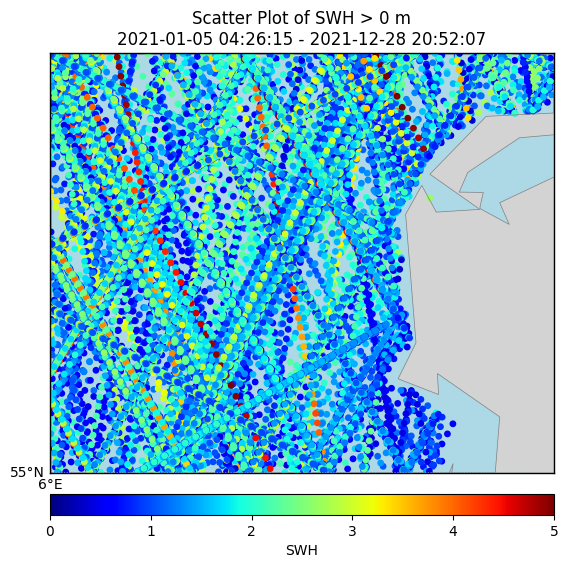

In [19]:
# Subset
timestep_2_plot = df.index.unique()[1]
df_subset = df.copy()

# Define bounding box
dxm = 20
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df_subset['longitude'].values, df_subset['latitude'].values)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df_subset['SWH'], s=15, marker='o',
    cmap=plt.cm.jet, vmin=0, vmax=5)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('SWH')

plt.title(f'Scatter Plot of SWH > 0 m\n{df.index[0]} - {df.index[-1]}')
plt.show()

# One big dataset...
Download the whole globe

In [ ]:
df = repo.download_copernicus_data(dataset_id=dataset,
                                                    start_time="2021-01-01",
                                                    end_time="2021-12-31")

In [ ]:
# Define bounding box
dxm = 20
lon_min = 0
lon_max = 359
lat_min = -90
lat_max = 90
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df['longitude'].values, df['latitude'].values)

# Create alpha mask: transparent if WS == 0.5
alpha_values = np.where(df['WS'] < 0.01, 0.0, 1.0)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df['WS'], s=1, marker='o',
               cmap=plt.cm.jet, vmin=0, vmax=10,
               alpha=alpha_values)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title('Scatter Plot of WS > 0 m/s')
plt.show()